In [1]:
import random, os

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score

import torch
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader

import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

from pytorch_metric_learning.samplers.m_per_class_sampler import MPerClassSampler
from pytorch_metric_learning.losses import TripletMarginLoss
from pytorch_metric_learning.miners import TripletMarginMiner

from IPython.display import clear_output
from tqdm.notebook import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

import wandb
_ = wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\anton\_netrc.
wandb: Currently logged in as: qwelly (some_ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [2]:
def set_random_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

set_random_seed()

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Данные

In [4]:
from torchvision.datasets import ImageFolder

train_ds = ImageFolder("data/training", transform=T.ToTensor())
test_ds = ImageFolder("data/testing", transform=T.ToTensor())

In [5]:
def validate_shapes(dataset):
    shapes = set()
    for i in range(0, len(dataset)):
        cur_shape = dataset[i][0].shape
        shapes.add(cur_shape)
    assert len(shapes) == 1, "Датасет содержит изображения разной формы"

validate_shapes(train_ds)
validate_shapes(test_ds)

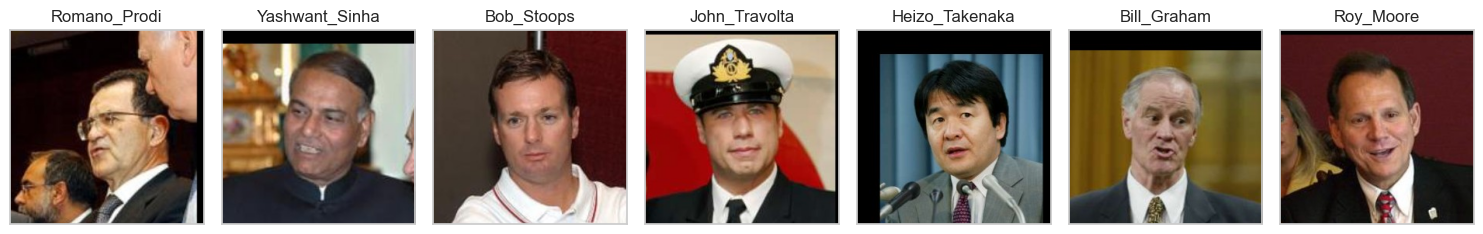

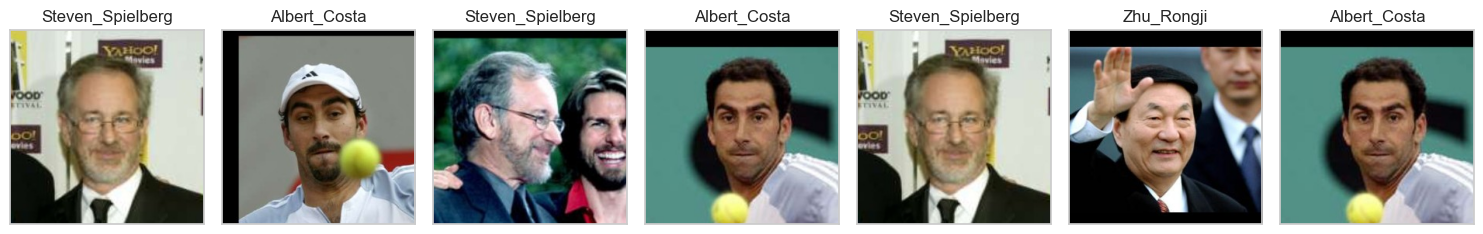

In [6]:
def plot_pictures(dataset, num_pics=7):
    random_indices = np.random.randint(0, len(dataset), num_pics)
    plt.figure(figsize=(15, 4))
    for n, index in enumerate(random_indices):
        plt.subplot(1, 7, n+1)
        pic, person = dataset[index]
        plt.imshow(pic.permute(1, 2, 0))
        plt.title(dataset.classes[person])
        plt.xticks([])
        plt.yticks([])
        plt.grid()
    
    plt.tight_layout()
    plt.show()

plot_pictures(train_ds)
plot_pictures(test_ds)

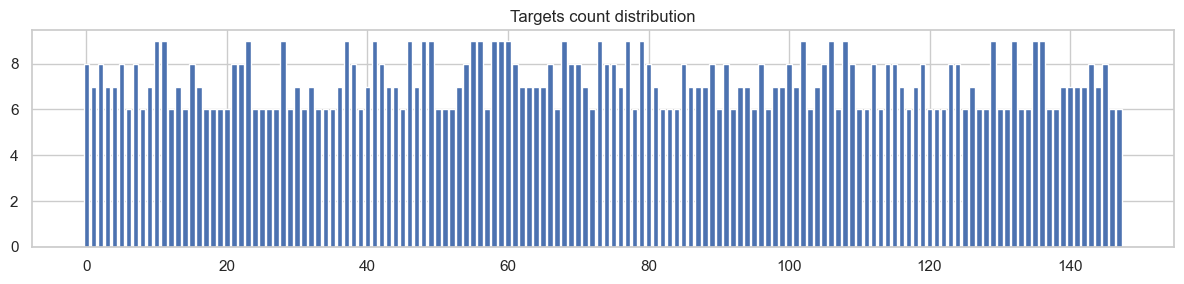

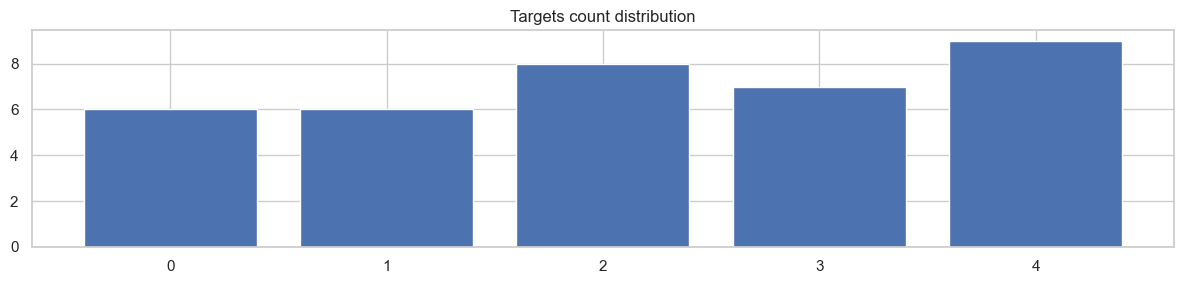

In [7]:
def plot_count(targets):
    plt.figure(figsize=(12, 3))
    classes, counts = np.unique(targets, return_counts=True)
    plt.bar(classes, counts)
    plt.title("Targets count distribution")
    plt.tight_layout()
    plt.show()

plot_count(train_ds.targets)
plot_count(test_ds.targets)

In [8]:
from torch.utils.data import random_split, Subset
train_indices, val_indices = random_split(range(len(train_ds)), [0.7, 0.3])

In [9]:
sample = Subset(train_ds, train_indices)
sample_loader = DataLoader(sample, 4096)

n = len(sample)
pic_size = 250**2

sum1 = torch.zeros(3)
sum2 = torch.zeros(3)

for x_batch, _ in sample_loader:
    sum1 += x_batch.sum(dim=(0, 2, 3))
    sum2 += torch.sum(x_batch**2, dim=(0, 2, 3))

mean = sum1 / (n * pic_size)
std = ((sum2 / (n * pic_size)) - mean**2)**0.5

In [10]:
train_transformer = T.Compose([
    T.RandomHorizontalFlip(),
    T.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    T.ToTensor(),
    T.Normalize(mean, std),
])

test_transformer = T.Compose([
    T.ToTensor(),
    T.Normalize(mean, std),
])

In [11]:
train_ds = ImageFolder("data/training", transform=train_transformer)
val_ds = ImageFolder("data/training", transform=test_transformer)
test_ds = ImageFolder("data/testing", transform=test_transformer)

train_ds = Subset(train_ds, train_indices)
val_ds = Subset(val_ds, val_indices)

print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

746
319
36


# Оценка качества

In [12]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, labels=None):
        self.dataset = dataset
        if labels is None:
            self.targets = [ self._get_target(i) for i in range(len(self)) ]
        else:
            self.targets = labels

    def _idx1(self, idx):
        return idx % len(self.dataset)
    
    def _idx2(self, idx):
        return idx // len(self.dataset)
    
    def _get_target(self, idx):
        return int(self.dataset.targets[self._idx1(idx)] != self.dataset.targets[self._idx2(idx)])

    def __len__(self):
        return len(self.dataset) ** 2

    def __getitem__(self, idx):
        image1, label1 = self.dataset[self._idx1(idx)]
        image2, label2 = self.dataset[self._idx2(idx)]
        return image1, image2, int(label1 != label2)

In [13]:
@torch.no_grad()
def get_auc_roc(model, pair_loader):
    preds = []
    targets = []
    model.eval()
    for images1, images2, labels in tqdm(pair_loader, desc="ROC-AUC"):
        emb1 = model(images1.to(device))
        emb2 = model(images2.to(device))
        dist = ((emb1 - emb2) ** 2).sum(dim = 1)
        preds.extend(dist.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = np.array(preds)
    targets = np.array(targets)
    return roc_auc_score(targets, preds)

# Цикл обучения

In [22]:
def train_epoch(model, dataloader, loss_func, optimizer, miner=None):

    model.train()

    epoch_loss = 0
    
    dataset_size = len(dataloader.dataset)

    for x_batch, y_batch in tqdm(dataloader, desc="train"):

        optimizer.zero_grad()
        
        x = x_batch.to(device)
        y = y_batch.to(device)

        out = model(x)
        if miner is not None:
            miner_out = miner(out, y)
            loss = loss_func(out, y, miner_out)
        else:
            loss = loss_func(out, y)

        loss.backward()
        optimizer.step()

        wandb.log({
            "train/batch-loss": loss.item(),
        })

        epoch_loss += loss.item()

    epoch_loss /= dataset_size

    return epoch_loss


@torch.no_grad()
def validate_epoch(model, dataloader, loss_func, miner=None):

    model.eval()

    epoch_loss = 0
    
    dataset_size = len(dataloader.dataset)

    for x_batch, y_batch in tqdm(dataloader, desc="valid"):
        
        x = x_batch.to(device)
        y = y_batch.to(device)

        out = model(x)
        if miner is not None:
            miner_out = miner(out, y)
            loss = loss_func(out, y, miner_out)
        else:
            loss = loss_func(out, y)

        epoch_loss += loss.item()

    epoch_loss /= dataset_size

    return epoch_loss


def train(model, train_loader, val_loader, loss_func, optimizer, num_epochs, early_stop_epochs=None, miner=None):

    prev_val_loss = None
    loss_best_model = None
    best_state = None
    stop_points = 0
    
    for epoch in range(1, num_epochs+1):
        clear_output()        
        print(f"EPOCH {epoch}:")

        train_loss = train_epoch(model, train_loader, loss_func, optimizer, miner)
        val_loss = validate_epoch(model, val_loader, loss_func, miner)

        if (early_stop_epochs is not None) and (prev_val_loss is not None):
            if (val_loss >= prev_val_loss) or np.isclose(prev_val_loss, val_loss, atol=1e-5):
                stop_points += 1

        with torch.no_grad():
            if (loss_best_model is None) or (val_loss < loss_best_model):
                loss_best_model = val_loss
                stop_points = 0
                best_state = {
                    k: v.cpu().clone()
                    for k, v in model.state_dict().items()
                }
                
        prev_val_loss = val_loss

        wandb.log(
            {
                "train/epoch-loss": train_loss,
                "validate/epoch-loss": val_loss,
            }
        )

        if (early_stop_epochs is not None) and (stop_points >= early_stop_epochs):
            print(f"Early stopped on {epoch} epoch")
            break

    model.load_state_dict(best_state)
    return loss_best_model

# Формирование батчей

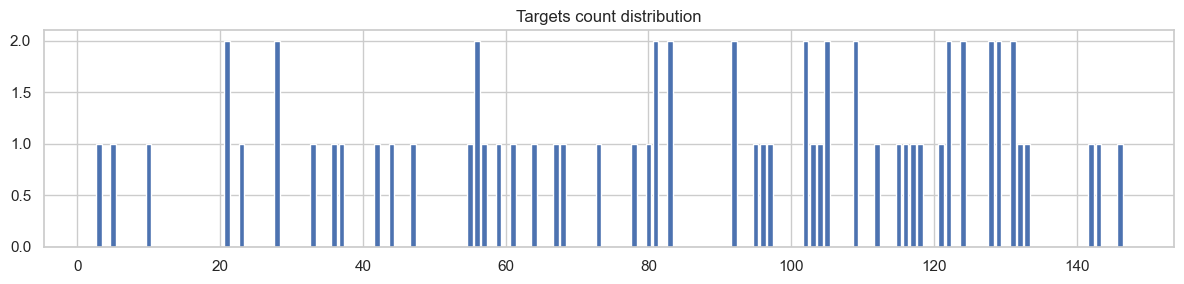

In [15]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
for x_batch, y_batch in train_loader:
    break
plot_count(y_batch)

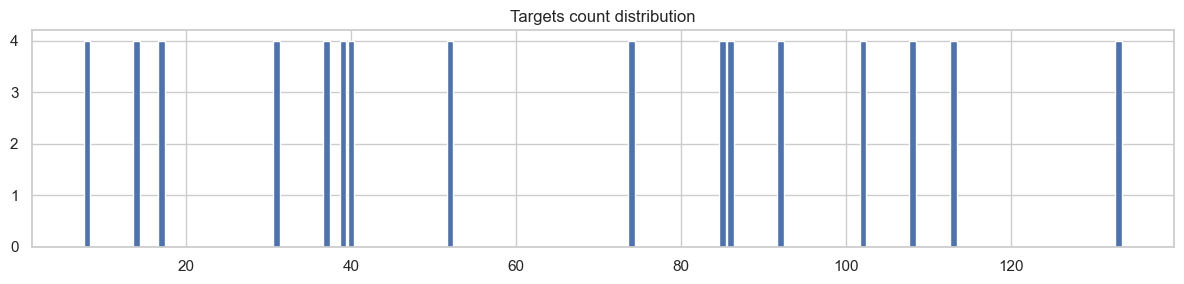

In [16]:
labels = np.array([
    train_ds.dataset.targets[i]
    for i in train_ds.indices
])
sampler = MPerClassSampler(
    labels,
    m=4,
    batch_size=64,
    length_before_new_iter=len(labels),
)

train_loader = DataLoader(train_ds, batch_size=64, sampler=sampler)
for x_batch, y_batch in train_loader:
    break
plot_count(y_batch)

# Обучение

In [106]:
def model_train(model, labels, train_ds, val_ds, val_pairs_loader, BATCH_SIZE, EPOCHS, LR, WD, M, MARGIN, count_roc_auc=True):
    
    optimizer = AdamW(model.parameters(), LR, weight_decay=WD)
    miner = TripletMarginMiner(MARGIN, type_of_triplets="hard")
    loss_func = TripletMarginLoss(MARGIN)
    
    sampler = MPerClassSampler(
        labels, M,
        BATCH_SIZE,
        length_before_new_iter=len(labels),
    )
    
    train_loader = DataLoader(
        train_ds,
        BATCH_SIZE,
        sampler=sampler,
        pin_memory=True,
    )
    val_loader = DataLoader(
        val_ds,
        4096,
        shuffle=False,
    )
    
    wandb.init(
        project="facial recognition",
        name="ResNet Metric Learing",
        config={
            "architecture": "ResNet18",
            "optimizer": "AdamW",
            "lr": LR,
            "weight_decay": WD,
            "loss_func": "TripletMarginLoss",
            "margin": MARGIN,
            "m_per_class": M,
            "epochs": EPOCHS,
        }
    )
    
    try:
        loss = train(
            model,
            train_loader,
            val_loader,
            loss_func,
            optimizer,
            EPOCHS,
            early_stop_epochs=5,
            miner=miner,
        )

        if count_roc_auc:
            roc_auc = get_auc_roc(model, val_pairs_loader)
            [wandb.log({"summary/roc_auc": roc_auc}) for _ in range(2)]
            wandb.summary["roc_auc"] = roc_auc
            return loss, roc_auc
        else:
            return loss
        
    finally:
        wandb.finish()

# GridSearch LR и WeighDecay

In [24]:
labels = np.array([
    train_ds.dataset.targets[i]
    for i in train_ds.indices
])

val_labels = np.array([
    val_ds.dataset.targets[i]
    for i in val_ds.indices
])

val_pairs = PairDataset(val_ds, val_labels)
val_pairs_loader = DataLoader(val_pairs, batch_size = 64, shuffle = False)

In [25]:
BATCH_SIZE = 64
EPOCHS = 15
M = 4
MARGIN = 0.2

LR_grid = np.logspace(-3, -5, 3)
WD_grid = np.logspace(-3, -6, 4)

losses = np.full(
    shape=(len(LR_grid), len(WD_grid)),
    fill_value=np.nan,
)
roc_aucs = losses.copy()

best_roc_auc = None
best_model_state = None
best_LR = None
best_WD = None

for i, LR in enumerate(LR_grid):
    for j, WD in enumerate(WD_grid):

        set_random_seed()
        model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Identity()
        model.to(device)

        loss, roc_auc = model_train(
            model, labels, train_ds, val_ds, val_pairs_loader, BATCH_SIZE, EPOCHS, LR, WD, M, MARGIN,
        )

        losses[i, j] = loss
        roc_aucs[i, j] = roc_auc

        if (best_roc_auc is None) or (roc_auc > best_roc_auc):
            best_roc_auc = roc_auc
            best_model_state = {
                k: v.cpu().clone()
                for k, v in model.state_dict().items()
            }
            best_LR = LR
            best_WD = WD

best_roc_auc

EPOCH 15:


train:   0%|          | 0/11 [00:00<?, ?it/s]

valid:   0%|          | 0/1 [00:00<?, ?it/s]

ROC-AUC:   0%|          | 0/1591 [00:00<?, ?it/s]

summary/roc_auc,▁▁
train/batch-loss,▆▇▆▇▇▇█▅▄▆▇▆▅▅▅▅▃▄▃▄▅▃▅▄▆▄▂▃▄▃▃▄▃▅▁▁▂▂▂▁
train/epoch-loss,█▇▆▆▅▄▃▄▃▃▂▂▁▁▁
validate/epoch-loss,█▅▄▃▂▂▂▂▂▁▁▁▁▁▁
roc_auc,0.86908
summary/roc_auc,0.86908
train/batch-loss,0.2166
train/epoch-loss,0.00326
validate/epoch-loss,0.00074


0.9514504852370718

In [47]:
def plot_heatmap(matrix, x_grid, y_grid, show=False):
    
    sns.heatmap(
        matrix,
        xticklabels=WD_grid,
        yticklabels=LR_grid,
    )

    if show:
        plt.show()

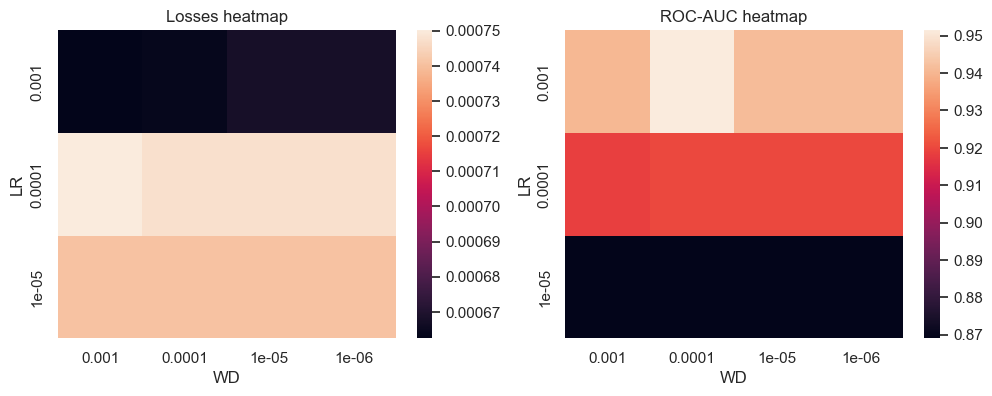

In [50]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("Losses heatmap")
plot_heatmap(losses, WD_grid, LR_grid)
plt.xlabel("WD")
plt.ylabel("LR")

plt.subplot(1, 2, 2)
plt.title("ROC-AUC heatmap")
plot_heatmap(roc_aucs, WD_grid, LR_grid)
plt.xlabel("WD")
plt.ylabel("LR")

plt.show()

In [111]:
torch.save(best_model_state, "ResNet.pkl")

# Тест

In [114]:
state_dict = torch.load("ResNet.pkl")
model = resnet18()
model.fc = nn.Identity()
model.load_state_dict(state_dict)
model.to(device)

test_pairs = PairDataset(test_ds)
test_pairs_loader = DataLoader(test_pairs, batch_size = 64, shuffle = False)
get_auc_roc(model, test_pairs_loader)

ROC-AUC:   0%|          | 0/21 [00:00<?, ?it/s]

0.9900576684429521